## Goal and how to run

Download the complete `.ipynb`. In VibeIt Studio's file browser use **+ → Import from Files**, then open it. Run code cells from top to bottom. Saved charts show actual executed results; rerunning recomputes them from embedded data.

This lesson assumes basic Python knowledge. Read each method and caption before changing parameters. AI exercises are optional; no AI account is needed for the core workflow. Data lives in notebook metadata, so there is no companion data download. Keep the notebook saved in the active working folder.

Your goal is to understand the research question, execute transparent calculations, check the results, and state the limits of the conclusion.

## Setup and parameters

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from scipy.optimize import brentq
from IPython.display import display as _display
def display(value):
    if isinstance(value,pd.DataFrame):
        table=value.to_html(max_rows=12,escape=True)
        style="<style>.vibeit-readable-table{max-width:100%;overflow-x:auto}.vibeit-readable-table table{width:max-content;max-width:none;border-collapse:collapse}.vibeit-readable-table td,.vibeit-readable-table th{white-space:nowrap!important;word-break:normal!important;overflow-wrap:normal!important}</style>"
        return _display(HTML(style+'<div class="vibeit-readable-table">'+table+'</div>'))
    return _display(value)
RECIPE_ID='ch04-titration'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### Load the embedded snapshot

The loader locates this notebook in the working folder by recipe ID and SHA-256, then decompresses and verifies the data. Renaming the file does not change its identity. If loading fails, check the working folder and saved file. Metadata travels with `.ipynb` save/export; copying code to a standalone `.py` does not copy the dataset.

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'models': '48fd2e6e706650fe2ee0c0ad80b6d794a546a1dec78dd9d370ac09db3cc3adbf'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['models']


### Read the method functions

The full implementations appear below. They use the listed bundled packages and standard library; no cookbook helper module is imported at runtime. Inspect input requirements and return values. If you change an algorithm, its checks must still pass.

In [3]:
def weak_acid_titration(acid_molar,acid_volume_L,base_molar,added_volume_L,pKa=4.76,Kw=1e-14):
    """Ideal dilute monoprotic-acid/strong-base charge balance, concentration model."""
    volumes=np.asarray(added_volume_L,dtype=float)
    if min(acid_molar,acid_volume_L,base_molar,Kw)<=0 or not np.isfinite(volumes).all() or np.any(volumes<0):
        raise ValueError('Invalid titration concentrations or volumes')
    Ka=10**(-pKa);pH=[];fractions=[];residuals=[]
    for added in volumes:
        total_volume=acid_volume_L+added;total_acid=acid_molar*acid_volume_L/total_volume;sodium=base_molar*added/total_volume
        def balance(log_h):
            H=10**log_h;anion=total_acid*Ka/(Ka+H)
            return H+sodium-Kw/H-anion
        log_h=brentq(balance,-16,1,xtol=1e-13)
        H=10**log_h;pH.append(-log_h);fractions.append(Ka/(Ka+H));residuals.append(balance(log_h))
    return dict(pH=np.asarray(pH),anion_fraction=np.asarray(fractions),charge_residual_mol_per_L=np.asarray(residuals))

print("Method ready: weak_acid_titration")


Method ready: weak_acid_titration


### Data and model boundary

PubChem properties and conformers are calculated database fields, not new experimental measurements. V2000 parsing here is intentionally limited to atoms, reported bonds and formal charges. Titration and calibration use stated ideal/simulated teaching assumptions. Water pressure uses the attributed IAPWS reference correlation. Descriptors, distances and visual proximity do not establish biological activity or binding strength.

## Steps

### 1. Solve charge balance over the full titration

For a monoprotic weak acid plus strong base, solve H+[Na+]−Kw/H−[A−]=0 with [A−]=Ct Ka/(Ka+H). This is an ideal concentration model at the declared temperature; activity corrections and real instrument response are excluded.

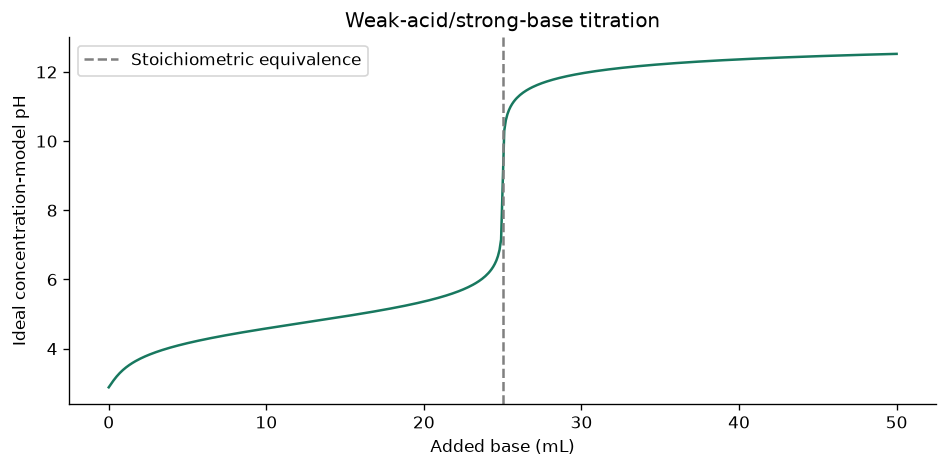

In [4]:
p=snapshot("models")["titration"]
added=np.linspace(0,.05,501)
result=weak_acid_titration(p["acid_initial_mol_per_L"],p["acid_volume_L"],p["base_mol_per_L"],added,p["pKa"],p["Kw"])
equivalence=p["acid_initial_mol_per_L"]*p["acid_volume_L"]/p["base_mol_per_L"]
fig,ax=plt.subplots(figsize=(8,4));ax.plot(1000*added,result["pH"])
ax.axvline(1000*equivalence,color="gray",linestyle="--",label="Stoichiometric equivalence")
ax.set(xlabel="Added base (mL)",ylabel="Ideal concentration-model pH",title="Weak-acid/strong-base titration");ax.legend();plt.tight_layout();plt.show()


### 2. Read species fractions

Plot fractions of total acid present as HA and A−. These fractions sum to one by mass balance. Large changes near the equivalence volume describe the ideal equilibrium calculation rather than direct concentration measurements.

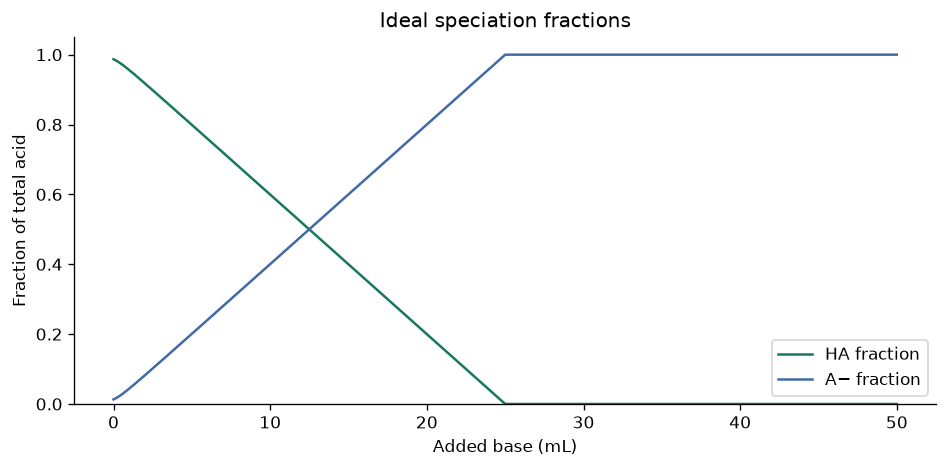

In [5]:
fraction=result["anion_fraction"]
fig,ax=plt.subplots(figsize=(8,4));ax.plot(1000*added,1-fraction,label="HA fraction");ax.plot(1000*added,fraction,label="A− fraction")
ax.set(xlabel="Added base (mL)",ylabel="Fraction of total acid",ylim=(0,1.05),title="Ideal speciation fractions");ax.legend();plt.tight_layout();plt.show()


### 3. Compare the buffer approximation in its intended interval

The Henderson–Hasselbalch comparison uses stoichiometric buffer amounts for 0<V<Veq. It is undefined at zero addition and equivalence in this form. Plot its difference from the full charge-balance solution instead of applying it across the whole curve.

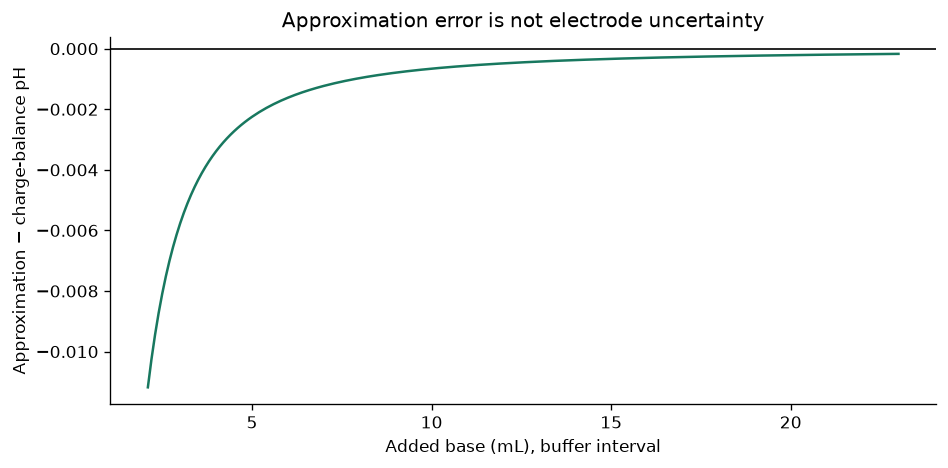

In [6]:
mask=(added>.002)&(added<equivalence-.002)
acid_moles=p["acid_initial_mol_per_L"]*p["acid_volume_L"];base_moles=p["base_mol_per_L"]*added[mask]
approximation=p["pKa"]+np.log10(base_moles/(acid_moles-base_moles))
fig,ax=plt.subplots(figsize=(8,4));ax.plot(1000*added[mask],approximation-result["pH"][mask])
ax.axhline(0,color="black",lw=1);ax.set(xlabel="Added base (mL), buffer interval",ylabel="Approximation − charge-balance pH",title="Approximation error is not electrode uncertainty");plt.tight_layout();plt.show()


### 4. Check electroneutrality and export assumptions

Verify the molar charge residual, monotonic titration response and near-pKa behavior at half-equivalence. pKa=4.76 and Kw are declared teaching inputs. None of these numerical checks substitutes for an experimental titration or activity model.

In [7]:
assert np.max(abs(result["charge_residual_mol_per_L"]))<1e-10
assert np.all(np.diff(result["pH"])>=-1e-9) and np.all((fraction>=0)&(fraction<=1))
half=weak_acid_titration(p["acid_initial_mol_per_L"],p["acid_volume_L"],p["base_mol_per_L"],np.array([equivalence/2]),p["pKa"],p["Kw"])
assert abs(half["pH"][0]-p["pKa"])<.01
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
pd.DataFrame({"base_volume_mL":added*1000,"ideal_pH":result["pH"],"anion_fraction":fraction,"charge_residual_mol_per_L":result["charge_residual_mol_per_L"]}).to_csv(OUTPUT_DIR/"ideal-titration.csv",index=False)
(OUTPUT_DIR/"assumptions.json").write_text(json.dumps(p,indent=2))
print("Mass/charge and half-equivalence checks passed; exports:",OUTPUT_DIR)


Mass/charge and half-equivalence checks passed; exports: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads/results/ch04-titration


## Exercises and reference explanation

1. Explain the half-equivalence comparison.
2. Where does the stoichiometric buffer approximation fail?

**Reference explanation.** Half-neutralized ideal weak acid has similar HA/A− amounts, so pH is near pKa. Initial/equivalence conditions cannot use the simple stoichiometric ratio expression.

Keep a copy before changing parameters. Compare old and new figures and record which inputs, calculations and conclusions changed.

## Optional AI coding exercises

Open the current notebook in VibeIt's Coding Agent and ask it to read the relevant cells. The core lesson does not depend on AI access; see the Help Center for provider and account setup.

**Prompt 1**

> Using NumPy/SciPy/Matplotlib, compare pKa=4.0, 4.76 and 5.5 with the same acid/base amounts.

**Prompt 2**

> Using the same packages, add a charge-residual panel without clipping the pH curve.

**Human acceptance.** Mass fractions stay in [0,1], charge balance passes and all volumes/concentrations are declared.

Review the edited source, then manually run affected cells and subsequent checks. Ask the assistant to explain the purpose, packages and data provenance of its changes, and reconcile that explanation with actual output.

## Optional online extension

The network action below is disabled by default. It reports a database version/source without replacing the core data. To refresh data, save a separate experimental version and record the new URL, database release, retrieval date and SHA-256. New results require rerunning and validation.

In [8]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.brentq.html',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## Sources, snapshots and next steps

- [IAPWS saturation reference release](https://iapws.org/public/documents/6dGkr/Supp-sat.pdf) — IAPWS SR1-86(1992): unrestricted publication allowed in all countries (cover page); retrieved 2026-10-09. SHA-256 `a10d38d73339b0713c86cfac88f9adcba137202167ccdfa1cd58238c438361d7`.
  Reference equations and numerical coefficients transcribed from release pages 2–3; pedagogical model values are not new experiments.

- [Authored numerical teaching model parameters](https://github.com/zhiluo20/vibeit/blob/main/cookbook-src/freeze_subject_data.py) — Original teaching parameters/code MIT; reference equation coefficients attributed to IAPWS SR1-86(1992); retrieved 2026-10-09. SHA-256 `4350c4305a83c772fa295a8be0ef86a247f2bfaae930a081720d3cd0c753abe0`.
  Declared parameters and seed; generated trajectories and calibration observations must be labelled simulated.


**Next steps.** Transfer these methods to your own public or authorized data while retaining input checks, recorded parameters and result validation. Document the new experimental design and method limits; this example does not validate a new experiment. Full data licenses and generation instructions accompany the cookbook.